In [4]:
#You are a junior data analyst at an international climate research institute working on SDG 13: Climate Action. You’ve been asked to produce a visual analysis of environmental relationships across countries. Your goal is to:

    #Create a dataset using key climate indicators
    #Transform and scale the data using matrix operations
    #Compute correlations between the indicators
    #Create a polished heatmap to visualize the results

ERROR: Error in parse(text = input): <text>:1:3: unexpected string constant
5:     Compute correlations between the indicators
6:     Create a polished heatmap to visualize the results"
     ^


In [7]:
#STEP 1: Create a matrix with 6 countries and 4 indicators:

    #CO₂ emissions per capita
    #Temperature anomaly (°C)
    #Deforestation rate (% forest loss)
    #Renewable energy share (% of total energy)

climate <- matrix(c(
  9.2, 1.1, 0.8, 15,
  6.5, 0.9, 1.2, 30,
  2.3, 0.7, 2.5, 60,
  3.8, 1.0, 1.5, 45,
  7.1, 1.2, 0.9, 25,
  4.2, 1.0, 2.1, 50
), nrow = 6, byrow = TRUE) #tells matrix() to fill the matrix ROW by ROW rather than column by column


colnames(climate) <- c("CO2", "Temp", "Deforestation", "Renewables")
rownames(climate) <- c("A", "B", "C", "D", "E", "F")

print(climate) #Matrix simulates six countries' environmental data

  CO2 Temp Deforestation Renewables
A 9.2  1.1           0.8         15
B 6.5  0.9           1.2         30
C 2.3  0.7           2.5         60
D 3.8  1.0           1.5         45
E 7.1  1.2           0.9         25
F 4.2  1.0           2.1         50


In [17]:
#STEP 2: Standardise data
scaled_climate <- scale(climate)
print(scaled_climate)

print("Why is scaling important before computing correlation?")
print("The algorithim naturally pays more attention to larger numbers/units and so there is accidental bias. Scaling all units to have  a mean of 0 and standard deviation of 1 removes this bias.")

         CO2        Temp Deforestation Renewables
A  1.4544133  0.67734887    -1.0320937 -1.3269776
B  0.3882823 -0.48382062    -0.4423259 -0.4423259
C -1.2701437 -1.64499012     1.4744196  1.3269776
D -0.6778487  0.09676412     0.0000000  0.4423259
E  0.6252003  1.25793362    -0.8846517 -0.7372098
F -0.5199034  0.09676412     0.8846517  0.7372098
attr(,"scaled:center")
          CO2          Temp Deforestation    Renewables 
    5.5166667     0.9833333     1.5000000    37.5000000 
attr(,"scaled:scale")
          CO2          Temp Deforestation    Renewables 
    2.5325218     0.1722401     0.6782330    16.9558250 
[1] "Why is scaling important before computing correlation?"
[1] "The algorithim naturally pays more attention to larger numbers/units and so there is accidental bias. Scaling all units to have  a mean of 0 and standard deviation of 1 removes this bias."


In [18]:
#STEP 3 - Compute the Correlation Matrix
cor_matrix <- cor(scaled_climate)
print(round(cor_matrix, 2)) #the relationship between all environmental indicators across countries.

                CO2  Temp Deforestation Renewables
CO2            1.00  0.71         -0.91      -0.99
Temp           0.71  1.00         -0.79      -0.74
Deforestation -0.91 -0.79          1.00       0.97
Renewables    -0.99 -0.74          0.97       1.00


In [19]:
#Step 4 - Melt the Matrix for Plotting
install.packages("reshape2")  # run only once
library(reshape2)

melted <- melt(cor_matrix)
head(melted) #reformats correlation matrix into long format for ggplot2.

Installing package into 'C:/Users/sofoc/AppData/Local/R/win-library/4.5'
(as 'lib' is unspecified)



package 'reshape2' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\sofoc\AppData\Local\Temp\Rtmp4iHI4S\downloaded_packages


,Var1,Var2,value
,<fct>,<fct>,<dbl>
1,CO2,CO2,1.0000000
2,Temp,CO2,0.7114442
3,Deforestation,CO2,-0.9117162
4,Renewables,CO2,-0.9862370
5,CO2,Temp,0.7114442
6,Temp,Temp,1.0000000


In [20]:
#Step 5 - The Heatmap
install.packages("ggplot2")  # run only once
library(ggplot2)

Installing package into 'C:/Users/sofoc/AppData/Local/R/win-library/4.5'
(as 'lib' is unspecified)



package 'ggplot2' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\sofoc\AppData\Local\Temp\Rtmp4iHI4S\downloaded_packages


[1] "clearly shows positive and negative correlations between indicators."


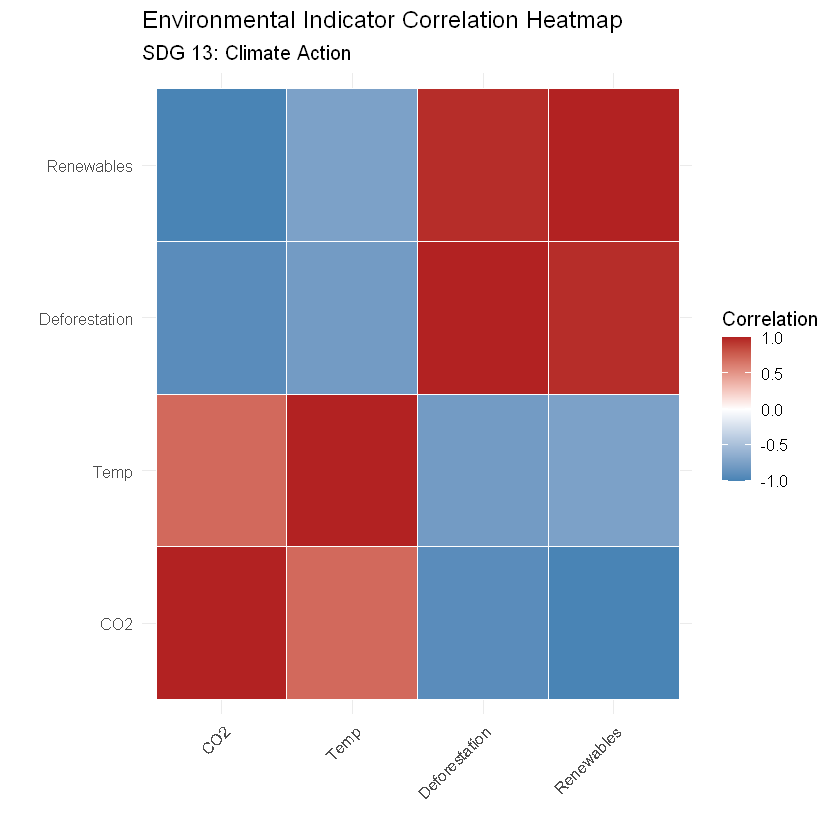

In [22]:
ggplot(melted, aes(x = Var1, y = Var2, fill = value)) +
  geom_tile(color = "white", linewidth = 0.5) +
  scale_fill_gradient2(
    low = "steelblue",
    high = "firebrick",
    mid = "white",
    midpoint = 0,
    limit = c(-1, 1),
    name = "Correlation"
  ) +
  theme_minimal(base_size = 12) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  labs(
    title = "Environmental Indicator Correlation Heatmap",
    subtitle = "SDG 13: Climate Action",
    x = "",
    y = ""
  )

#clearly shows positive and negative correlations between indicators.

In [23]:
#Step 6 - Modify & Observe:  Increase the renewable energy share in Country C (row 3)
climate[3, 4] <- 90  # new renewables value for Country C
scaled_climate <- scale(climate)
cor_matrix <- cor(scaled_climate)
melted <- melt(cor_matrix)


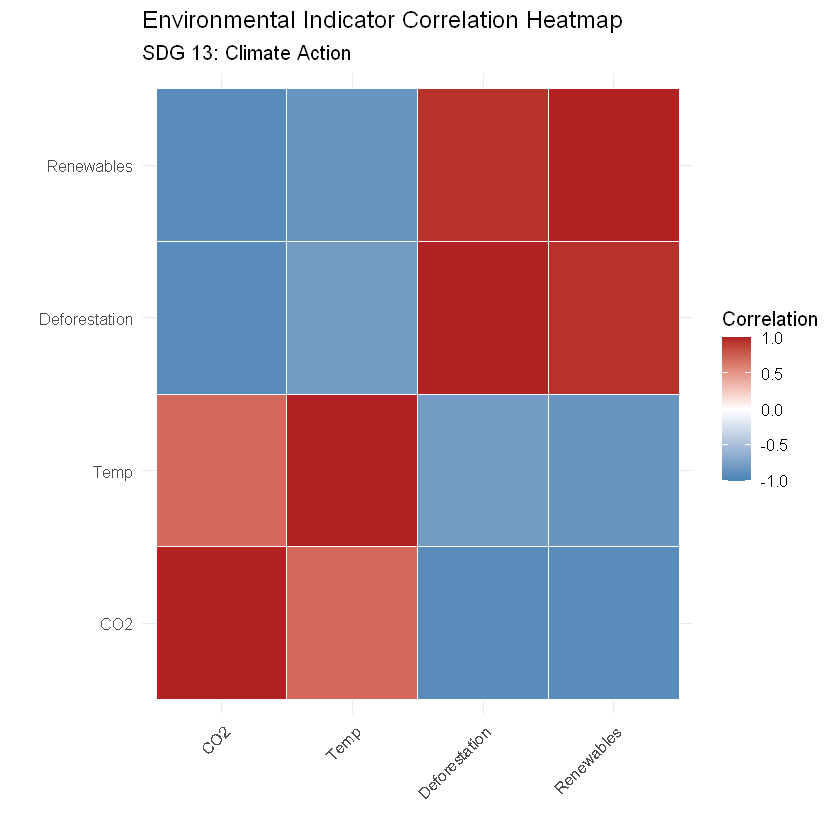

In [24]:
#Replotting Heat Map
ggplot(melted, aes(x = Var1, y = Var2, fill = value)) +
  geom_tile(color = "white", linewidth = 0.5) +
  scale_fill_gradient2(
    low = "steelblue",
    high = "firebrick",
    mid = "white",
    midpoint = 0,
    limit = c(-1, 1),
    name = "Correlation"
  ) +
  theme_minimal(base_size = 12) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  labs(
    title = "Environmental Indicator Correlation Heatmap",
    subtitle = "SDG 13: Climate Action",
    x = "",
    y = ""
  )


In [26]:
print("How did this change the correlation between renewables and the other variables?")
print("The correlation between renewabels have changed more noticeably for Temperature and Deforestation as the colours grew darker. Possibly less than 0.5.") 

[1] "How did this change the correlation between renewables and the other variables?"
[1] "The correlation between renewabels have changed more noticeably for Temperature and Deforestation as the colours grew darker. Possibly less than 0.5."
